<a href="https://www.kaggle.com/code/maximendacleu/digit-recognizer?scriptVersionId=332965159" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Handwritten Digit Recognition with Machine Learning

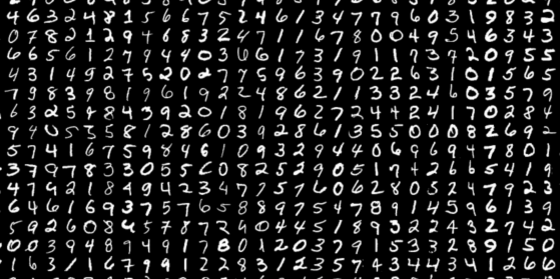

This notebook tackles the Kaggle Digit Recognizer challenge. Given a grayscale image of a handwritten single digit, the model must predict the correct label.

## 1. Importing required libraries

The first step is to import the libraries that will support data handling, visualization, model training, and validation. `Pandas` and `NumPy` are used for structured data manipulation, `Matplotlib` and `Seaborn` for visual analysis, `scikit-learn` for the classifier and evaluation metrics, and `Tensorflow` for improving deep learning workflows.

In [12]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and inspect the dataset

A quick inspection of shape and sample rows is essential before building the model.

In [13]:
project_dir = Path.cwd()
train_path = project_dir / "/kaggle/input/competitions/digit-recognizer/train.csv"
test_path = project_dir / "/kaggle/input/competitions/digit-recognizer/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTraining columns (first 5):", list(train_df.columns[:5]))
print("Training columns (last 3):", list(train_df.columns[-3:]))

display(Markdown(f"Training set: **{train_df.shape[0]}** rows and **{train_df.shape[1]}** columns."))
display(Markdown(f"Test set: **{test_df.shape[0]}** rows and **{test_df.shape[1]}** columns."))

display(train_df.head(3))
display(test_df.head(3))

Training shape: (42000, 785)
Test shape: (28000, 784)

Training columns (first 5): ['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3']
Training columns (last 3): ['pixel781', 'pixel782', 'pixel783']


Training set: **42000** rows and **785** columns.

Test set: **28000** rows and **784** columns.

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Exploratory data analysis (EDA)

The EDA step will helps us understand whether the digits are balanced across classes and whether the pixel intensities follow a consistent pattern.

Missing pixel values in training data: 0

Label distribution:
label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188


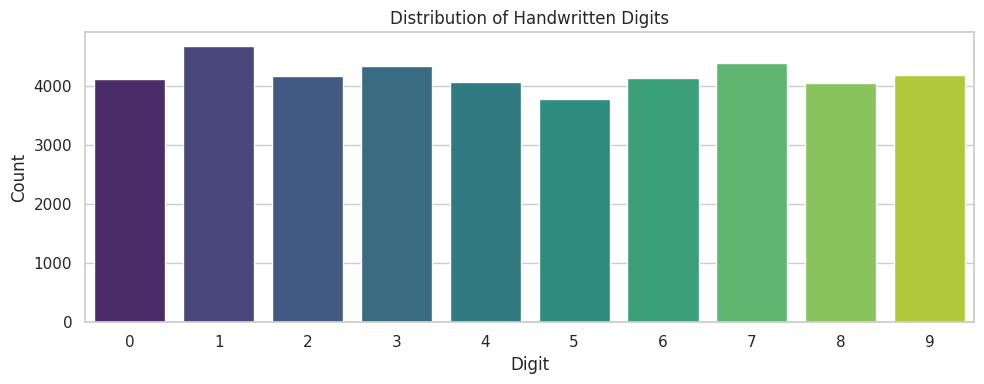

In [14]:
label_column = train_df.columns[0]
X = train_df.drop(columns=[label_column]).astype(np.float32)
y = train_df[label_column].astype(int)

missing_total = int(X.isna().sum().sum())
print("Missing pixel values in training data:", missing_total)
print("\nLabel distribution:")
print(y.value_counts().sort_index().to_string())

label_counts = y.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=label_counts.index.astype(int), y=label_counts.values, palette="viridis", ax=ax)
ax.set_title("Distribution of Handwritten Digits")
ax.set_xlabel("Digit")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

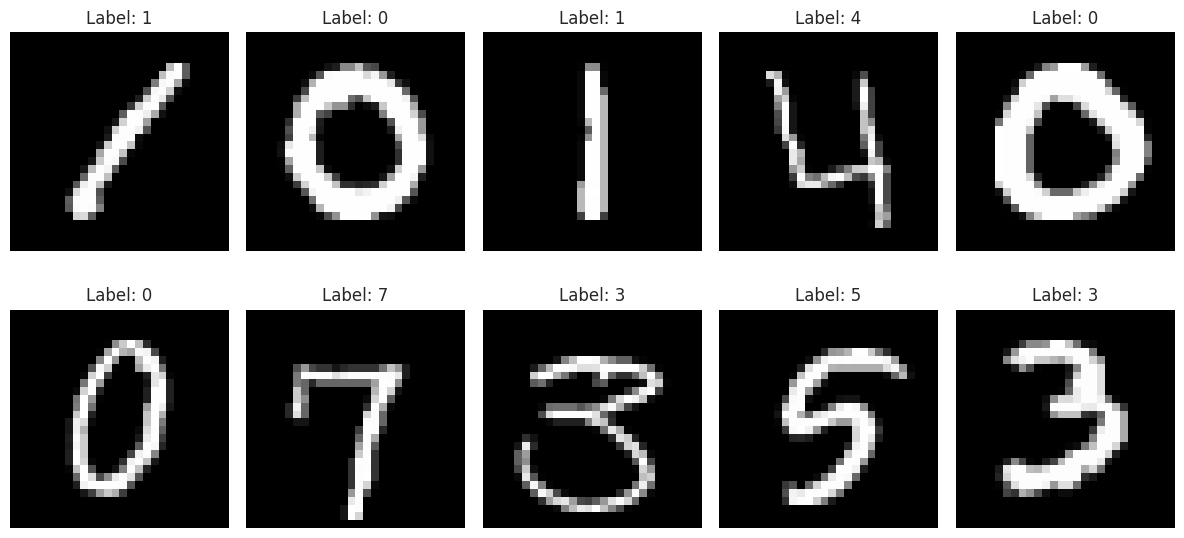

In [15]:
# Reshape the flattened pixels into 28x28 grayscale images for visualization.
img_matrix = X.values.reshape(-1, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for ax, img, label in zip(axes.flat, img_matrix[:10], y.iloc[:10].values):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Interpretation of the EDA results

The plots above show that the images are visually coherent and that each label corresponds to a recognizable handwritten shape. This means that our model is learning from meaningful pixel patterns rather than from noise. The next step is to scale the pixel values so that the optimizer can train the model efficiently.

## 4. Data preprocessing and normalization

In [16]:
# Normalize pixel intensities to the range [0, 1].
X = (X / 255.0).values.reshape(-1, 28, 28, 1).astype("float32")
X_test = (test_df.astype(np.float32) / 255.0).values.reshape(-1, 28, 28, 1)

# Convert labels to one-hot vectors for categorical cross-entropy.
y_encoded = to_categorical(y, num_classes=10)

print("Pixel value range after normalization:", X.min(), "to", X.max())
print("Training image shape:", X.shape)
print("Test image shape:", X_test.shape)

Pixel value range after normalization: 0.0 to 1.0
Training image shape: (42000, 28, 28, 1)
Test image shape: (28000, 28, 28, 1)


## 5. Train-validation split

Before fitting the model, the training data is divided into a training subset and a validation subset. The validation set allows us to estimate how well the model generalizes to unseen examples without touching the test labels.

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Training labels shape:", y_train.shape)

Training set shape: (33600, 28, 28, 1)
Validation set shape: (8400, 28, 28, 1)
Training labels shape: (33600, 10)


## 6. Building and training the classification model

A compact convolutional neural network (CNN) is trained here because it is better suited to image data. CNN layers learn local spatial patterns such as curves, corners, and strokes, which are essential for recognizing handwritten digits. To make the model more robust, the notebook uses small data augmentation transforms and training callbacks that can improve generalization on unseen images.

Epoch 1/12
263/263 ━━━━━━━━━━━━━━━━━━━━ 44s 151ms/step - accuracy: 0.8336 - loss: 0.5254 - val_accuracy: 0.4227 - val_loss: 5.3787 - learning_rate: 0.0010
Epoch 2/12
263/263 ━━━━━━━━━━━━━━━━━━━━ 40s 152ms/step - accuracy: 0.9411 - loss: 0.1983 - val_accuracy: 0.9463 - val_loss: 0.1688 - learning_rate: 0.0010
Epoch 3/12
263/263 ━━━━━━━━━━━━━━━━━━━━ 39s 149ms/step - accuracy: 0.9556 - loss: 0.1503 - val_accuracy: 0.9798 - val_loss: 0.0682 - learning_rate: 0.0010
Epoch 4/12
263/263 ━━━━━━━━━━━━━━━━━━━━ 39s 148ms/step - accuracy: 0.9662 - loss: 0.1224 - val_accuracy: 0.9802 - val_loss: 0.0744 - learning_rate: 0.0010
Epoch 5/12
263/263 ━━━━━━━━━━━━━━━━━━━━ 42s 159ms/step - accuracy: 0.9676 - loss: 0.1157 - val_accuracy: 0.9715 - val_loss: 0.1051 - learning_rate: 0.0010
Epoch 6/12
263/263 ━━━━━━━━━━━━━━━━━━━━ 41s 156ms/step - accuracy: 0.9746 - loss: 0.0879 - val_accuracy: 0.9792 - val_loss: 0.0641 - learning_rate: 5.0000e-04
Epoch 7/12
263/263 ━━━━━━━━━━━━━━━━━━━━ 40s 151ms/step - accuracy:

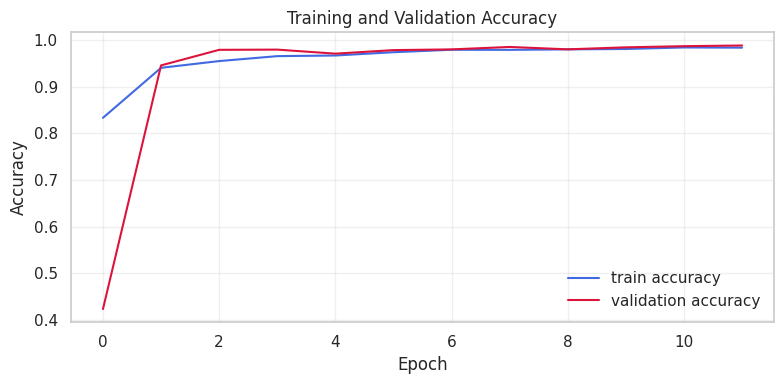

In [18]:
data_augmentation = models.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=128,
    callbacks=callbacks,
    verbose=1,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history["accuracy"], label="train accuracy", color="royalblue")
ax.plot(history.history["val_accuracy"], label="validation accuracy", color="crimson")
ax.set_title("Training and Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Model performance evaluation

The validation set provides a realistic estimate of generalization ability. Accuracy is the key competition metric, but the classification report and confusion matrix reveal whether particular digits are systematically confused with others.

Validation accuracy: 0.989

Classification report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       827
           1       1.00      0.99      1.00       937
           2       0.99      0.99      0.99       835
           3       0.99      0.99      0.99       870
           4       0.97      0.99      0.98       814
           5       0.99      0.99      0.99       759
           6       0.99      1.00      0.99       827
           7       0.98      0.99      0.98       880
           8       0.99      0.99      0.99       813
           9       1.00      0.96      0.98       838

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400



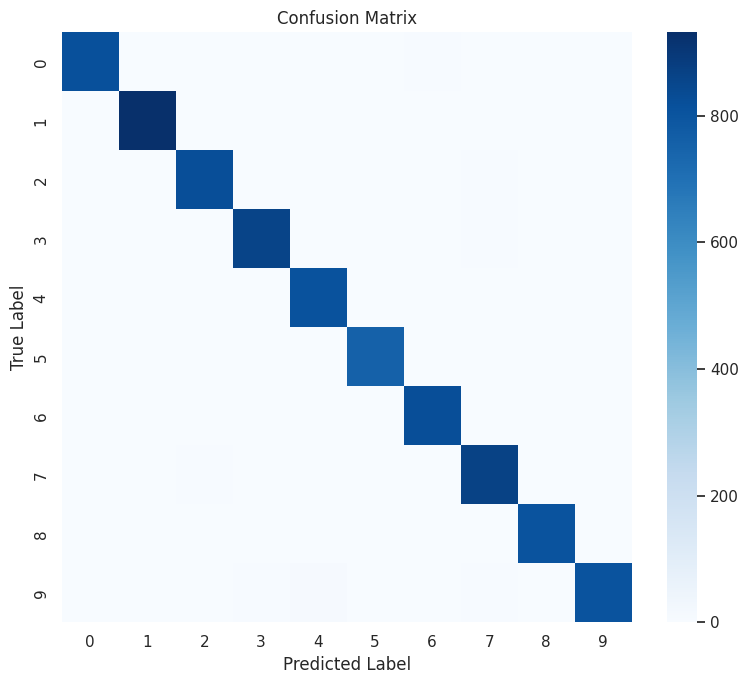

The validation accuracy is approximately **98.90%**

In [19]:
val_prob = model.predict(X_val, verbose=0)
val_pred = np.argmax(val_prob, axis=1)
true_labels = np.argmax(y_val, axis=1)
accuracy = accuracy_score(true_labels, val_pred)

print("Validation accuracy:", round(accuracy, 4))
print("\nClassification report:\n")
print(classification_report(true_labels, val_pred))

cm = confusion_matrix(true_labels, val_pred)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=False, cmap="Blues", fmt="d", ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

display(Markdown(f"The validation accuracy is approximately **{accuracy:.2%}**"))

## 8. Predictions for the test set

In [20]:
test_prob = model.predict(X_test, verbose=0)
test_pred = np.argmax(test_prob, axis=1)

sample_indices = np.arange(10)
for idx in sample_indices:
    print(f"Sample {idx}: predicted digit {test_pred[idx]}")

submission = pd.DataFrame({"ImageID": np.arange(1, len(test_pred) + 1), "Label": test_pred.astype(int)})
submission.head()

Sample 0: predicted digit 2
Sample 1: predicted digit 0
Sample 2: predicted digit 9
Sample 3: predicted digit 0
Sample 4: predicted digit 3
Sample 5: predicted digit 7
Sample 6: predicted digit 0
Sample 7: predicted digit 3
Sample 8: predicted digit 0
Sample 9: predicted digit 3


,ImageID,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


In [21]:
submission_path = project_dir / "submission.csv"
kaggle_output_path = Path("/kaggle/working/submission.csv")

submission.to_csv(submission_path, index=False)
submission.to_csv(kaggle_output_path, index=False)

print("Submission saved to:", submission_path)
print("Kaggle output saved to:", kaggle_output_path)
print("CSV files in current directory:")
for path in sorted(project_dir.glob("*.csv")):
    print(" -", path.name)

Submission saved to: /kaggle/working/submission.csv
Kaggle output saved to: /kaggle/working/submission.csv
CSV files in current directory:
 - submission.csv
